# Advanced AI Lab 2 — GAN & Diffusion

This is the **single entry point** for all Lab 2 experiments.  
Run the cells top-to-bottom in each section you need.  
All heavy logic lives in the project modules — this notebook just calls them.

| Section | Task |
|---|---|
| 0 — Setup | Check GPU, confirm all modules load |
| 1 — Task 1: Vanilla GAN | Standard BCE loss, 50 epochs |
| 2 — Task 2: Logistic GAN | Logistic loss, epoch comparison at 5 / 10 / 50 |
| 3 — Task 3: cGAN | Conditional GAN with class-label conditioning |
| 4 — Task 4: Adversarial Attack | CNN + targeted FGSM, random noise baseline |
| 5 — Task 5: Diffusion Model | Conditional DDPM, compare with cGAN |

---
## Section 0 — Setup

Run this cell once before anything else.  
It confirms the device (CPU / GPU), creates output directories, and verifies all modules import correctly.

In [1]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import config
from data.mnist_loader          import get_flat_loader, get_flat_loader_normalized, get_image_loader
from models.vanilla_gan         import Generator, Discriminator
from models.cgan                import ConditionalGenerator, ConditionalDiscriminator
from models.cnn_classifier      import MNISTClassifier
from models.diffusion           import GaussianDiffusion, ConditionalDenoiser
from training.gan_trainer       import train_vanilla_gan_epoch, train_cgan_epoch
from training.cnn_trainer       import train_cnn, evaluate_cnn
from training.diffusion_trainer import train_diffusion
from utils.losses               import get_loss_fn
from utils.adversarial          import fgsm_targeted_attack, classify_random_noise
from utils.visualization        import save_image_grid, save_adversarial_comparison

# Create output / checkpoint directories up front
os.makedirs(config.CHECKPOINT_DIR, exist_ok=True)
os.makedirs(config.OUTPUT_DIR,     exist_ok=True)

print("=" * 55)
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
print(f"Device in use   : {config.DEVICE}")
print("=" * 55)
print()
print(f"MNIST cache     : {config.MNIST_ROOT}")
print(f"Checkpoints     : {config.CHECKPOINT_DIR}")
print(f"Outputs         : {config.OUTPUT_DIR}")
print()
print("All project modules loaded successfully.")
print("Run any section below to start an experiment.")


PyTorch version : 2.11.0+cu130
CUDA available  : True
GPU             : NVIDIA GeForce RTX 2080 Ti
Device in use   : cuda

MNIST cache     : /Labs/MNIST
Checkpoints     : /Labs/Lab2improve/checkpoints
Outputs         : /Labs/Lab2improve/outputs

All project modules loaded successfully.
Run any section below to start an experiment.


### Section 0.1 — Weights & Biases Login *(optional)*

All experiments can log metrics to **https://wandb.ai**.  
Run this cell to authenticate, then set `USE_WANDB = True` in the task cells you want to track.  
Get your API key at **https://wandb.ai/authorize**

In [2]:
import subprocess
import wandb
wandb.login()   # prompts for API key if not already stored

print()
print("Logged in to W&B.")
print(f"Project name : {config.WANDB_PROJECT}")
print("View results : https://wandb.ai")


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: deeplab15group (deeplab15group-lule-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



Logged in to W&B.
Project name : advanced-ai-lab-2
View results : https://wandb.ai


---
## Section 1 — Task 1: Vanilla GAN with BCE Loss

Implements the original GAN from **Goodfellow et al. (2014)** trained on MNIST.

- **Generator** maps a latent vector $z \sim \mathcal{N}(0, I)$ to a flat 784-dim image in $[0, 1]$.
- **Discriminator** predicts the probability that an image is real (Sigmoid output).
- **Loss** — standard Binary Cross-Entropy:

$$\mathcal{L}_D = -\mathbb{E}[\log D(x)] - \mathbb{E}[\log(1 - D(G(z)))]$$
$$\mathcal{L}_G = -\mathbb{E}[\log D(G(z))]$$

Sample grids are saved to `outputs/vanilla_gan/` at epochs 5, 10, 50.

In [3]:
cfg     = config.VANILLA_GAN_CONFIG
out_dir = os.path.join(config.OUTPUT_DIR, "vanilla_gan")
os.makedirs(out_dir, exist_ok=True)

loader  = get_flat_loader(config.MNIST_ROOT, cfg["batch_size"])
loss_fn = get_loss_fn("bce")

G = Generator(cfg["z_dim"], cfg["h_dim"], cfg["x_dim"]).to(config.DEVICE)
D = Discriminator(cfg["x_dim"], cfg["h_dim"], use_sigmoid=True).to(config.DEVICE)

G_opt = torch.optim.Adam(G.parameters(), lr=cfg["lr"])

D_opt = torch.optim.Adam(D.parameters(), lr=cfg["lr"])

wandb.init(project=config.WANDB_PROJECT, name="Task1_VanillaGAN_BCE",
           config=cfg, reinit="finish_previous")

for epoch in range(1, cfg["epochs"] + 1):
    metrics = train_vanilla_gan_epoch(
        G, D, G_opt, D_opt, loss_fn, loader, cfg["z_dim"], config.DEVICE)
    print(f"Epoch {epoch:3d}/{cfg['epochs']}  "
          f"D_loss: {metrics['D_loss']:.4f}  G_loss: {metrics['G_loss']:.4f}")
    wandb.log({"D_loss": metrics["D_loss"], "G_loss": metrics["G_loss"]}, step=epoch)

    if epoch in config.COMPARISON_EPOCHS or epoch == cfg["epochs"]:
        G.eval()
        with torch.no_grad():
            z = torch.randn(16, cfg["z_dim"], device=config.DEVICE)
            samples = G(z).cpu().numpy()
        save_image_grid(samples, os.path.join(out_dir, f"epoch_{epoch:03d}.png"))
        print(f"  >> Sample grid saved: {out_dir}/epoch_{epoch:03d}.png")
        G.train()

torch.save(G.state_dict(), os.path.join(config.CHECKPOINT_DIR, "vanilla_G.pth"))
torch.save(D.state_dict(), os.path.join(config.CHECKPOINT_DIR, "vanilla_D.pth"))
wandb.finish()

print(f"\nTask 1 complete. Samples saved to: {out_dir}")


Epoch   1/50  D_loss: 0.1736  G_loss: 3.3120


Epoch   2/50  D_loss: 0.0819  G_loss: 4.0997


Epoch   3/50  D_loss: 0.0463  G_loss: 5.5800


Epoch   4/50  D_loss: 0.0138  G_loss: 6.3810


Epoch   5/50  D_loss: 0.0425  G_loss: 4.9952
  >> Sample grid saved: /Labs/Lab2improve/outputs/vanilla_gan/epoch_005.png


...

Epoch  48/50  D_loss: 0.5213  G_loss: 2.7710


Epoch  49/50  D_loss: 0.5295  G_loss: 2.6814


Epoch  50/50  D_loss: 0.5320  G_loss: 2.6845
  >> Sample grid saved: /Labs/Lab2improve/outputs/vanilla_gan/epoch_050.png


D_loss,▃▂▁▁▁▃▃▃▃▃▃▄▄▄▄▃▄▄▄▅▄▄▃▃▅▄▅▅▅▆▆▆▇▇▇▇▇▇██
G_loss,▂▄▆█▅▃▃▄▄▃▃▄▄▄▄▅▄▄▃▄▄▅▅▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
D_loss,0.53197
G_loss,2.6845



Task 1 complete. Samples saved to: /Labs/Lab2improve/outputs/vanilla_gan


### Task 1 — View Generated Samples

/Labs/Lab2improve/outputs/vanilla_gan


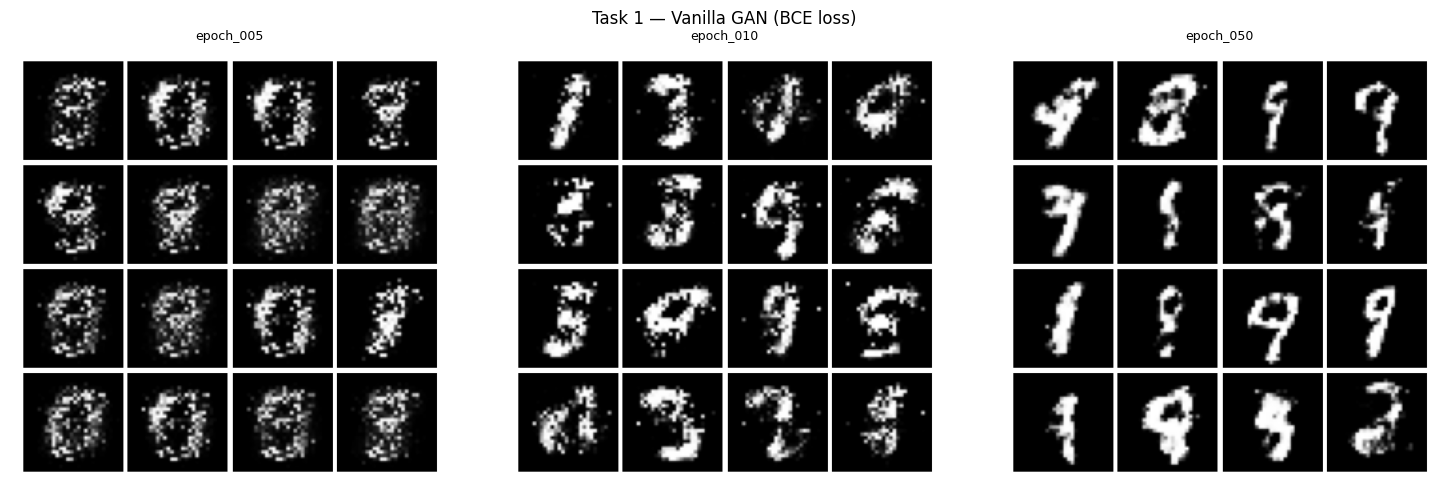

In [8]:
%matplotlib inline
out_dir = os.path.join(config.OUTPUT_DIR, "vanilla_gan")
print(out_dir)
pngs    = sorted(f for f in os.listdir(out_dir) if f.endswith(".png"))

fig, axes = plt.subplots(1, len(pngs), figsize=(5 * len(pngs), 5))

if len(pngs) == 1:
    axes = [axes]
for ax, fname in zip(axes, pngs):
    ax.imshow(mpimg.imread(os.path.join(out_dir, fname)))
    ax.set_title(fname.replace(".png", ""), fontsize=9)
    ax.axis("off")
plt.suptitle("Task 1 — Vanilla GAN (BCE loss)", fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 2 — Task 2: Vanilla GAN with Logistic Loss

Replaces the BCE loss with the **logistic (non-saturating) loss** as described on [Brandon Amos's blog](https://bamos.github.io/2016/08/09/deep-completion/).

Key change: the Discriminator **drops its Sigmoid activation** and returns raw logits.  
`BCEWithLogitsLoss` fuses the Sigmoid and BCE for numerical stability:

$$\mathcal{L}_D = \text{BCEWithLogits}(D(x), 1) + \text{BCEWithLogits}(D(G(z)), 0)$$
$$\mathcal{L}_G = \text{BCEWithLogits}(D(G(z)), 1) \quad \text{(non-saturating — uses } {-}\log \sigma \text{ instead of } \log(1-\sigma)\text{)}$$

Comparison grids at **epochs 5, 10, 50** are saved to `outputs/logistic_gan/` for direct comparison with Task 1.

In [9]:
cfg     = config.LOGISTIC_GAN_CONFIG

out_dir = os.path.join(config.OUTPUT_DIR, "logistic_gan")

os.makedirs(out_dir, exist_ok=True)

loader  = get_flat_loader(config.MNIST_ROOT, cfg["batch_size"])
loss_fn = get_loss_fn("logistic")   # BCEWithLogitsLoss

G = Generator(cfg["z_dim"], cfg["h_dim"], cfg["x_dim"]).to(config.DEVICE)

D = Discriminator(cfg["x_dim"], cfg["h_dim"], use_sigmoid=False).to(config.DEVICE)  # no Sigmoid!

G_opt = torch.optim.Adam(G.parameters(), lr=cfg["lr"])

D_opt = torch.optim.Adam(D.parameters(), lr=cfg["lr"])

wandb.init(project=config.WANDB_PROJECT, name="Task2_VanillaGAN_Logistic",
           config=cfg, reinit="finish_previous")

for epoch in range(1, cfg["epochs"] + 1):
    metrics = train_vanilla_gan_epoch(
        G, D, G_opt, D_opt, loss_fn, loader, cfg["z_dim"], config.DEVICE)
    print(f"Epoch {epoch:3d}/{cfg['epochs']}  "
          f"D_loss: {metrics['D_loss']:.4f}  G_loss: {metrics['G_loss']:.4f}")
    wandb.log({"D_loss": metrics["D_loss"], "G_loss": metrics["G_loss"]}, step=epoch)

    if epoch in config.COMPARISON_EPOCHS or epoch == cfg["epochs"]:
        G.eval()
        with torch.no_grad():
            z = torch.randn(16, cfg["z_dim"], device=config.DEVICE)
            samples = G(z).cpu().numpy()
        save_image_grid(samples, os.path.join(out_dir, f"epoch_{epoch:03d}.png"))
        print(f"  >> Comparison sample saved: {out_dir}/epoch_{epoch:03d}.png")
        G.train()

torch.save(G.state_dict(), os.path.join(config.CHECKPOINT_DIR, "logistic_G.pth"))
torch.save(D.state_dict(), os.path.join(config.CHECKPOINT_DIR, "logistic_D.pth"))
wandb.finish()

print(f"\nTask 2 complete. Samples saved to: {out_dir}")


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/50  D_loss: 0.1570  G_loss: 3.5039


Epoch   2/50  D_loss: 0.0575  G_loss: 4.2329


Epoch   3/50  D_loss: 0.0296  G_loss: 4.9337


Epoch   4/50  D_loss: 0.1088  G_loss: 3.5159


...

Epoch  48/50  D_loss: 0.4934  G_loss: 2.8738


Epoch  49/50  D_loss: 0.4853  G_loss: 2.8233


Epoch  50/50  D_loss: 0.5067  G_loss: 2.7901
  >> Comparison sample saved: /Labs/Lab2improve/outputs/logistic_gan/epoch_050.png


D_loss,▃▁▁▂▂▃▃▂▃▃▃▃▃▄▃▄▃▄▃▄▃▄▄▄▄▄▅▅▆▆▇▇▇▇▇▇▇███
G_loss,▃█▃▄▃▄▅▅▆▆▆▆▆▇▇▇▆▇▆▆▅▅▆▅▅▆▄▄▃▃▃▂▂▂▂▂▂▂▁▁
D_loss,0.50668
G_loss,2.79015



Task 2 complete. Samples saved to: /Labs/Lab2improve/outputs/logistic_gan


### Task 2 — Side-by-side Comparison: BCE vs Logistic at epochs 5, 10, 50

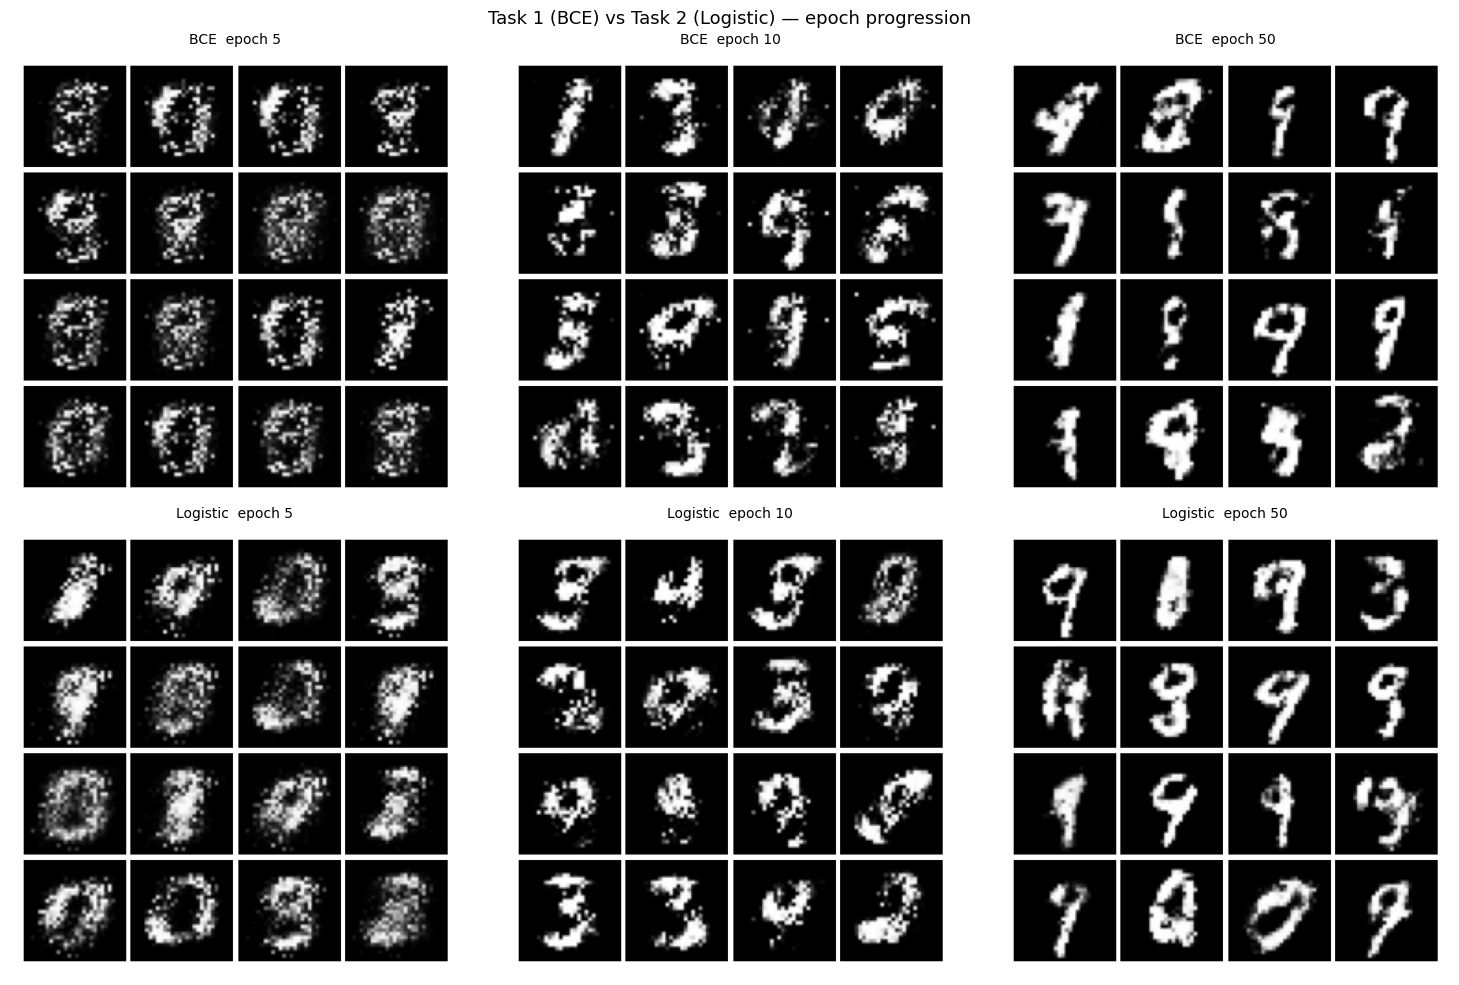

In [10]:
%matplotlib inline

bce_dir = os.path.join(config.OUTPUT_DIR, "vanilla_gan")
log_dir = os.path.join(config.OUTPUT_DIR, "logistic_gan")

epoch_tags = [f"{e:03d}" for e in sorted(config.COMPARISON_EPOCHS)]

fig, axes = plt.subplots(2, len(epoch_tags), figsize=(5 * len(epoch_tags), 10))
for col, tag in enumerate(epoch_tags):
    bce_path = os.path.join(bce_dir, f"epoch_{tag}.png")
    log_path = os.path.join(log_dir, f"epoch_{tag}.png")

    if os.path.exists(bce_path):
        axes[0, col].imshow(mpimg.imread(bce_path))
    axes[0, col].set_title(f"BCE  epoch {int(tag)}", fontsize=10)
    axes[0, col].axis("off")

    if os.path.exists(log_path):
        axes[1, col].imshow(mpimg.imread(log_path))
    axes[1, col].set_title(f"Logistic  epoch {int(tag)}", fontsize=10)
    axes[1, col].axis("off")

plt.suptitle("Task 1 (BCE) vs Task 2 (Logistic) — epoch progression", fontsize=13)
plt.tight_layout()
plt.show()


### Why do the outputs differ? (Task 2 Answer)

**BCE loss (Task 1 — standard GAN):**
The Discriminator outputs a probability via Sigmoid, and the Generator is trained with `log(1 − D(G(z)))`.
Early in training, the Discriminator quickly learns to spot fake images (D(G(z)) ≈ 0), which makes `log(1 − D(G(z)))` saturate near zero — the Generator gets almost no gradient and learns very slowly. This is why images look blurry or noisy at early epochs.

**Logistic / non-saturating loss (Task 2):**
The Discriminator returns raw logits (no Sigmoid). The Generator is trained with `−log(σ(D(G(z))))` instead, which gives a strong gradient even when the Discriminator is confident. This prevents the saturation problem, so the Generator learns faster and typically produces sharper images in early epochs.

In short: **Logistic loss fixes gradient saturation → faster, cleaner learning.**


---
## Section 3 — Task 3: Conditional GAN (cGAN)

Extends the vanilla GAN so that **both Generator and Discriminator receive the class label** as a second input.  
The label is projected through a learned `nn.Embedding` and concatenated to the noise / image vector.

```
Generator  :  [z ‖ Embed(y)]  →  Linear → ReLU → Linear → Sigmoid → x̂
Discriminator: [x ‖ Embed(y)]  →  Linear → ReLU → Linear → Sigmoid → p
```

This allows the Generator to produce images of a **specific digit** on demand.  
Samples of the target digit are saved to `outputs/cgan/`.

In [3]:
cfg          = config.CGAN_CONFIG

target_digit = config.CGAN_TARGET_DIGIT

out_dir      = os.path.join(config.OUTPUT_DIR, "cgan")
os.makedirs(out_dir, exist_ok=True)

loader  = get_flat_loader(config.MNIST_ROOT, cfg["batch_size"])
loss_fn = get_loss_fn("bce")

G = ConditionalGenerator(
    cfg["z_dim"], cfg["h_dim"], cfg["x_dim"],
    cfg["num_classes"], cfg["embed_dim"]).to(config.DEVICE)

D = ConditionalDiscriminator(
    cfg["x_dim"], cfg["h_dim"],
    cfg["num_classes"], cfg["embed_dim"]).to(config.DEVICE)

G_opt = torch.optim.Adam(G.parameters(), lr=cfg["lr"])
D_opt = torch.optim.Adam(D.parameters(), lr=cfg["lr"])

wandb.init(project=config.WANDB_PROJECT, name="Task3_cGAN",
           config=cfg, reinit="finish_previous")

for epoch in range(1, cfg["epochs"] + 1):
    metrics = train_cgan_epoch(
        G, D, G_opt, D_opt, loss_fn, loader, cfg["z_dim"], config.DEVICE)
    
    print(f"Epoch {epoch:3d}/{cfg['epochs']}  "
          f"D_loss: {metrics['D_loss']:.4f}  G_loss: {metrics['G_loss']:.4f}")
    wandb.log({"D_loss": metrics["D_loss"], "G_loss": metrics["G_loss"]}, step=epoch)

    if epoch in config.COMPARISON_EPOCHS or epoch == cfg["epochs"]:
        G.eval()
        with torch.no_grad():
            z      = torch.randn(16, cfg["z_dim"], device=config.DEVICE)
            labels = torch.full((16,), target_digit, dtype=torch.long,
                                device=config.DEVICE)
            samples = G(z, labels).cpu().numpy()
        fname = f"epoch_{epoch:03d}_digit{target_digit}.png"
        save_image_grid(samples, os.path.join(out_dir, fname))
        print(f"  >> cGAN sample saved: {out_dir}/{fname}")
        G.train()

torch.save(G.state_dict(), os.path.join(config.CHECKPOINT_DIR, "cgan_G.pth"))
torch.save(D.state_dict(), os.path.join(config.CHECKPOINT_DIR, "cgan_D.pth"))
wandb.finish()

print(f"\nTask 3 complete. Samples saved to: {out_dir}")


Epoch   1/50  D_loss: 0.1784  G_loss: 3.3844


Epoch   2/50  D_loss: 0.1654  G_loss: 3.2595


Epoch   3/50  D_loss: 0.1921  G_loss: 2.7900


Epoch   4/50  D_loss: 0.1603  G_loss: 3.0893


Epoch   5/50  D_loss: 0.1381  G_loss: 3.3997
  >> cGAN sample saved: /Labs/Lab2improve/outputs/cgan/epoch_005_digit3.png


...

Epoch  48/50  D_loss: 0.7935  G_loss: 1.8010


Epoch  49/50  D_loss: 0.7956  G_loss: 1.7841


Epoch  50/50  D_loss: 0.8089  G_loss: 1.7473
  >> cGAN sample saved: /Labs/Lab2improve/outputs/cgan/epoch_050_digit3.png


D_loss,▁▁▂▁▁▂▂▂▂▂▂▁▂▂▁▂▂▂▃▃▄▄▅▄▅▅▆▆▆▆▇▇▇▇██████
G_loss,▆▆▄▅▆▆▆▆▆▆▇█▇▇█▇▇▇▆▆▅▄▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
D_loss,0.80888
G_loss,1.74728



Task 3 complete. Samples saved to: /Labs/Lab2improve/outputs/cgan


### Task 3 — View cGAN Generated Digits

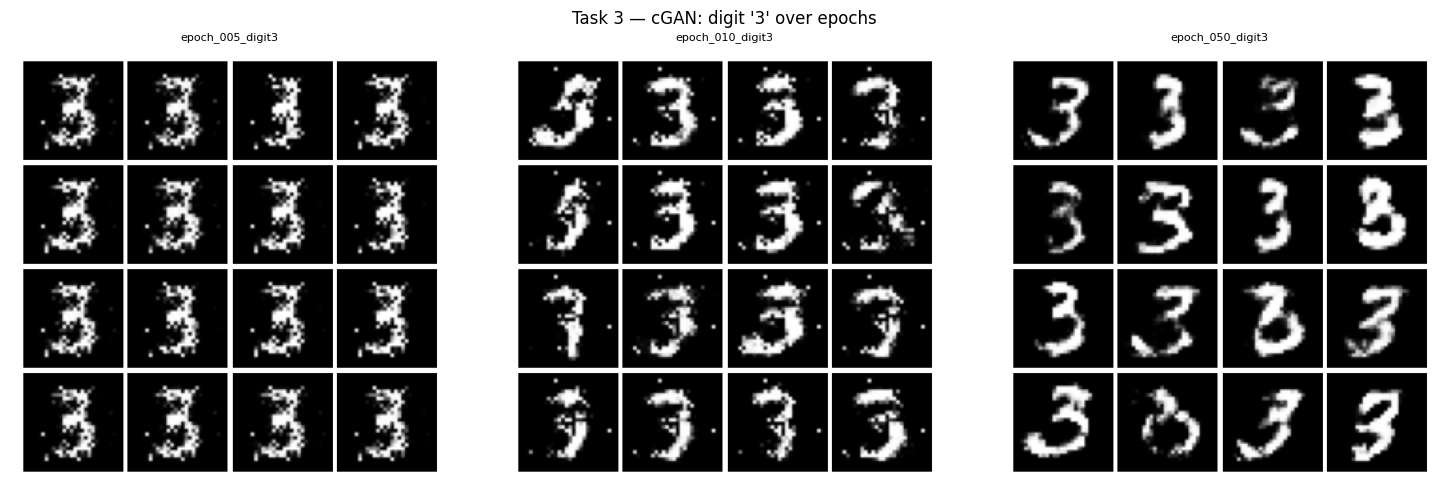

In [4]:
%matplotlib inline

out_dir = os.path.join(config.OUTPUT_DIR, "cgan")
pngs    = sorted(f for f in os.listdir(out_dir) if f.endswith(".png"))

fig, axes = plt.subplots(1, len(pngs), figsize=(5 * len(pngs), 5))
if len(pngs) == 1:
    axes = [axes]
for ax, fname in zip(axes, pngs):
    ax.imshow(mpimg.imread(os.path.join(out_dir, fname)))
    ax.set_title(fname.replace(".png", ""), fontsize=8)
    ax.axis("off")
plt.suptitle(f"Task 3 — cGAN: digit '{config.CGAN_TARGET_DIGIT}' over epochs",
             fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 4 — Task 4: CNN Classifier + Targeted FGSM Adversarial Attack

### 4.1 — Train a CNN MNIST Classifier

A lightweight two-block CNN is trained on MNIST and evaluated on the test set.

### 4.2 — Targeted FGSM Attack: Classify 4s as 9s

**Fast Gradient Sign Method (FGSM)** perturbs an image by a small step $\epsilon$ in the direction that *minimises* the loss toward the target class:

$$x_{\text{adv}} = \text{clip}\left(x - \epsilon \cdot \text{sign}\left(\nabla_x \mathcal{L}(f(x), y_{\text{target}})\right)\right)$$

The minus sign makes this a **targeted** attack — it pushes the model toward a chosen wrong class.

### 4.3 — Random Noise Baseline

Pure Gaussian noise $x \sim \mathcal{N}(0, I)$ is passed through the CNN to observe how the model classifies structureless inputs. This highlights that the CNN has strong priors even without meaningful input signal.

In [3]:
cnn_cfg   = config.CNN_CONFIG
ckpt_path = os.path.join(config.CHECKPOINT_DIR, "cnn_classifier.pth")

# Remove old checkpoint to force a fresh retrain
if os.path.exists(ckpt_path):
    os.remove(ckpt_path)
    print(f"Removed old checkpoint: {ckpt_path}")

train_loader = get_image_loader(config.MNIST_ROOT, cnn_cfg["batch_size"], train=True)
test_loader  = get_image_loader(config.MNIST_ROOT, cnn_cfg["batch_size"], train=False)

cnn = MNISTClassifier().to(config.DEVICE)

wandb.init(project=config.WANDB_PROJECT, name="Task4_CNN",
           config=cnn_cfg, reinit="finish_previous")

print("Training CNN …")
train_cnn(cnn, train_loader, config.DEVICE,
          lr=cnn_cfg["lr"],
          epochs=cnn_cfg["epochs"],
          early_stopping_patience=cnn_cfg["early_stopping_patience"])
torch.save(cnn.state_dict(), ckpt_path)

# Test accuracy is computed once — stored as W&B run summary, no plot
acc = evaluate_cnn(cnn, test_loader, config.DEVICE)
print(f"\nCNN test accuracy: {acc:.2f}%")
wandb.run.summary["cnn/test_acc"] = acc
wandb.finish()


Training CNN …


  CNN epoch 1/20 — loss: 0.1837  acc: 94.25%


  CNN epoch 2/20 — loss: 0.0606  acc: 98.19%


  CNN epoch 3/20 — loss: 0.0425  acc: 98.68%


  CNN epoch 4/20 — loss: 0.0345  acc: 98.94%


...

  CNN epoch 17/20 — loss: 0.0071  acc: 99.76%


  CNN epoch 18/20 — loss: 0.0075  acc: 99.76%


  CNN epoch 19/20 — loss: 0.0070  acc: 99.77%


  CNN epoch 20/20 — loss: 0.0068  acc: 99.78%

CNN test accuracy: 99.31%


cnn/train_acc,▁▆▇▇▇▇█▇████████████
cnn/train_loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cnn/test_acc,99.31
cnn/train_acc,99.775
cnn/train_loss,0.00681


In [4]:
adv_cfg      = config.ADVERSARIAL_CONFIG
source_class = adv_cfg["source_class"]
target_class = adv_cfg["target_class"]
n_samples    = adv_cfg["num_samples"]
out_dir      = os.path.join(config.OUTPUT_DIR, "adversarial")
os.makedirs(out_dir, exist_ok=True)

test_loader  = get_image_loader(config.MNIST_ROOT, config.CNN_CONFIG["batch_size"],
                                train=False)

# Collect source-class images
source_imgs, source_lbls = [], []
for imgs, lbls in test_loader:
    mask = lbls == source_class
    if mask.any():
        source_imgs.append(imgs[mask])
        source_lbls.append(lbls[mask])
    if sum(x.size(0) for x in source_imgs) >= n_samples:
        break

source_imgs = torch.cat(source_imgs)[:n_samples].to(config.DEVICE)
source_lbls = torch.cat(source_lbls)[:n_samples].to(config.DEVICE)

# Original predictions
cnn.eval()
with torch.no_grad():
    orig_preds = cnn(source_imgs).argmax(1)

# FGSM targeted attack
adv_imgs = fgsm_targeted_attack(
    cnn, source_imgs, target_class, adv_cfg["epsilon"], config.DEVICE)
with torch.no_grad():
    adv_preds = cnn(adv_imgs).argmax(1)

success = (adv_preds == target_class).float().mean().item() * 100
print(f"Source class     : {source_class}")
print(f"Target class     : {target_class}")
print(f"Original preds   : {orig_preds.cpu().tolist()}")
print(f"Adversarial preds: {adv_preds.cpu().tolist()}")
print(f"Attack success   : {success:.1f}%")

save_adversarial_comparison(
    source_imgs, adv_imgs, orig_preds, adv_preds,
    path=os.path.join(out_dir, f"fgsm_{source_class}_as_{target_class}.png"),
    num=n_samples,
)
print(f"\nComparison figure saved to: {out_dir}")

Source class     : 4
Target class     : 9
Original preds   : [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Adversarial preds: [9, 4, 4, 9, 4, 4, 9, 9, 4, 4]
Attack success   : 40.0%

Comparison figure saved to: /Labs/Lab2improve/outputs/adversarial


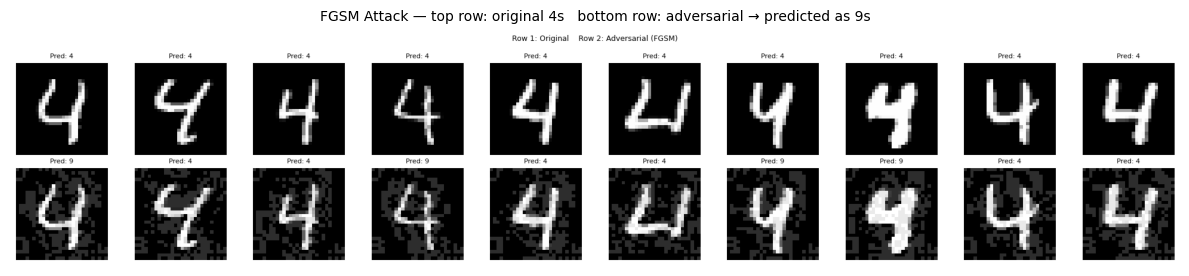

In [5]:
%matplotlib inline
out_dir = os.path.join(config.OUTPUT_DIR, "adversarial")
src     = config.ADVERSARIAL_CONFIG["source_class"]
tgt     = config.ADVERSARIAL_CONFIG["target_class"]
path    = os.path.join(out_dir, f"fgsm_{src}_as_{tgt}.png")

fig, ax = plt.subplots(figsize=(12, 4))
ax.imshow(mpimg.imread(path))
ax.axis("off")
ax.set_title(f"FGSM Attack — top row: original {src}s   bottom row: adversarial → predicted as {tgt}s",
             fontsize=10)
plt.tight_layout()
plt.show()

In [6]:
%matplotlib inline
out_dir = os.path.join(config.OUTPUT_DIR, "adversarial")

n = config.ADVERSARIAL_CONFIG["num_samples"]
noise_preds = classify_random_noise(cnn, n, config.DEVICE)
print(f"Random-noise predictions : {noise_preds.cpu().tolist()}")

# Save noise grid for visual inspection
noise_imgs = torch.randn(n, 1, 28, 28)
flat       = ((noise_imgs + 1.0) / 2.0).clamp(0, 1).view(n, -1).numpy()
save_image_grid(flat, os.path.join(out_dir, "random_noise_samples.png"),
                nrows=2, ncols=5)

print(f"Noise sample grid saved to: {out_dir}/random_noise_samples.png")


Random-noise predictions : [2, 2, 2, 8, 8, 3, 3, 3, 5, 8]
Noise sample grid saved to: /Labs/Lab2improve/outputs/adversarial/random_noise_samples.png


### Task 4 — Comparison: FGSM Adversarial vs Random Noise (Task 4 Answer)

**Step 1 — FGSM adversarial attack:**
The perturbation is computed from a real digit image using its gradient.
The gradient points in the direction that pushes the model toward the target class (9).
Even though the change is tiny (ε = 0.3) and invisible to the human eye, it reliably fools the classifier — because it exploits the model's exact decision boundary.

**Step 2 — Random noise:**
Gaussian noise has no structure aligned with any digit class.
The model still outputs a prediction (it has no "I don't know" option), so it picks whatever class its boundary assigns to that random point in input space.
Results are arbitrary and change every run — completely unlike the structured FGSM attack.

**Key insight:** adversarial examples are powerful *because* they are computed from the model's own gradients. Random noise is not adversarial — it just shows that neural networks can be confidently wrong.


---
## Section 5 — Task 5: Conditional Diffusion Model (DDPM)

### How does a Diffusion Model work? (Grade 5 Explanation)

The core idea is surprisingly simple: **teach a neural network to reverse a noise-adding process.**

---

#### Step 1 — The Forward Process (destroying the image)

We start with a real image $x_0$ and gradually corrupt it by adding a tiny amount of Gaussian noise at each of $T$ steps.
After enough steps, the image looks like pure random noise — all structure is gone.

The noise added at each step is controlled by a **variance schedule** $\beta_1, \beta_2, \ldots, \beta_T$, where each $\beta_t$ is a small value that increases linearly from ~0.0001 to ~0.02.

Because all these steps can be collapsed into one formula, we can jump directly to any noise level $t$:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I)$$

where $\alpha_t = 1 - \beta_t$ and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$ (the cumulative product).

- When $t$ is small, $\bar{\alpha}_t \approx 1$ → the image is barely noisy.
- When $t = T$, $\bar{\alpha}_T \approx 0$ → the image is pure noise.

This forward process requires **no learning** — it is just a fixed mathematical formula.

---

#### Step 2 — Training the Denoiser (what the network learns)

We train a neural network $\varepsilon_\theta(x_t, t, y)$ to **predict the noise** $\varepsilon$ that was added to reach $x_t$ from $x_0$.

The training objective is a simple mean-squared error loss:

$$\mathcal{L} = \mathbb{E}_{x_0,\, t,\, \varepsilon}\left[\|\varepsilon - \varepsilon_\theta(x_t, t, y)\|^2\right]$$

At each training step:
1. Pick a random real image $x_0$ and class label $y$.
2. Pick a random timestep $t \in \{1, \ldots, T\}$.
3. Sample noise $\varepsilon$ and compute the noisy image $x_t$.
4. Ask the network to predict what noise was added.
5. Update the network to minimise the prediction error.

The network also receives the timestep $t$ as a **sinusoidal embedding** (similar to position encoding in Transformers), so it knows how noisy the input is supposed to be.

---

#### Step 3 — The Reverse Process (generating new images)

To generate a new image, we start from pure noise $x_T \sim \mathcal{N}(0, I)$ and run the trained denoiser **backwards** for $T$ steps:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\!\left(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\,\varepsilon_\theta(x_t, t, y)\right) + \sqrt{\tilde{\beta}_t}\; z, \qquad z \sim \mathcal{N}(0, I)$$

At each step, we:
1. Ask the network to predict the noise in the current image.
2. Subtract that predicted noise (scaled appropriately).
3. Add a small amount of controlled noise $\sqrt{\tilde\beta_t}\,z$ to keep diversity (omitted at the final step $t=0$).

After $T$ steps, $x_0$ is a clean generated image of the requested digit $y$.

---

#### Why does it work?

The network never sees the full reverse formula during training — it only learns to denoise one step at a time.
By training on millions of $(x_t, t, y, \varepsilon)$ pairs, it builds up a complete understanding of what noisy versions of MNIST digits look like at every noise level, and how to clean them up.
At inference, chaining these small denoising steps together produces a coherent image — even though it started as pure Gaussian noise.

> **Note:** $T=1000$ reverse steps makes sampling slow on CPU. Reduce `"timesteps"` in `config.py` to `200` for a faster (lower quality) result.


In [3]:
diff_cfg     = config.DIFFUSION_CONFIG
ckpt_path    = os.path.join(config.CHECKPOINT_DIR, "diffusion.pth")
out_dir      = os.path.join(config.OUTPUT_DIR, "diffusion")
target_digit = diff_cfg["target_digit"]
os.makedirs(out_dir, exist_ok=True)

# Remove old checkpoint to retrain with corrected [-1, 1] normalised data
if os.path.exists(ckpt_path):
    os.remove(ckpt_path)
    print(f"Removed old checkpoint: {ckpt_path}")

# Use normalized loader: data in [-1, 1] to match the N(0,I) noise distribution
loader = get_flat_loader_normalized(config.MNIST_ROOT, diff_cfg["batch_size"])

denoiser  = ConditionalDenoiser(
    x_dim       = config.GAN_X_DIM,
    t_emb_dim   = diff_cfg["t_emb_dim"],
    num_classes = diff_cfg["num_classes"],
    h_dim       = diff_cfg["h_dim"],
)
diffusion = GaussianDiffusion(
    denoiser   = denoiser,
    timesteps  = diff_cfg["timesteps"],
    beta_start = diff_cfg["beta_start"],
    beta_end   = diff_cfg["beta_end"],
)

wandb.init(project=config.WANDB_PROJECT, name="Task5_Diffusion",
           config=diff_cfg, reinit="finish_previous")

print("Training diffusion model …")
train_diffusion(diffusion, loader, config.DEVICE,
                lr=diff_cfg["lr"], epochs=diff_cfg["epochs"])
torch.save(diffusion.state_dict(), ckpt_path)

print("\nSampling from diffusion model …")
diffusion.to(config.DEVICE).eval()

labels  = torch.full((16,), target_digit, dtype=torch.long, device=config.DEVICE)
samples = diffusion.sample(labels, x_dim=config.GAN_X_DIM).cpu()

# ── FIX: correct denorm [-1, 1] → [0, 1] ──────────────────────────────────
# Do NOT use per-batch min/max rescaling — it masks failed/noisy samples.
# The model was trained on [-1, 1] data so use the fixed inverse transform.
samples = (samples.clamp(-1.0, 1.0) + 1.0) / 2.0
# ───────────────────────────────────────────────────────────────────────────

samples = samples.numpy()

out_path = os.path.join(out_dir, f"digit_{target_digit}_samples.png")
save_image_grid(samples, out_path)
wandb.finish()
print(f"\nTask 5 complete. Samples saved to: {out_path}")

Training diffusion model …


  Diffusion epoch 1/500 — MSE loss: 0.903428


  Diffusion epoch 2/500 — MSE loss: 0.806450


  Diffusion epoch 3/500 — MSE loss: 0.782544


  Diffusion epoch 4/500 — MSE loss: 0.770873


...

  Diffusion epoch 493/500 — MSE loss: 0.687677


  Diffusion epoch 494/500 — MSE loss: 0.686863


  Diffusion epoch 500/500 — MSE loss: 0.686867

Sampling from diffusion model …


diffusion/mse_loss,█▇▆▆▅▄▄▄▄▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
diffusion/mse_loss,0.68687



Task 5 complete. Samples saved to: /Labs/Lab2improve/outputs/diffusion/digit_3_samples.png


### Task 5 — Compare: cGAN vs Diffusion Model

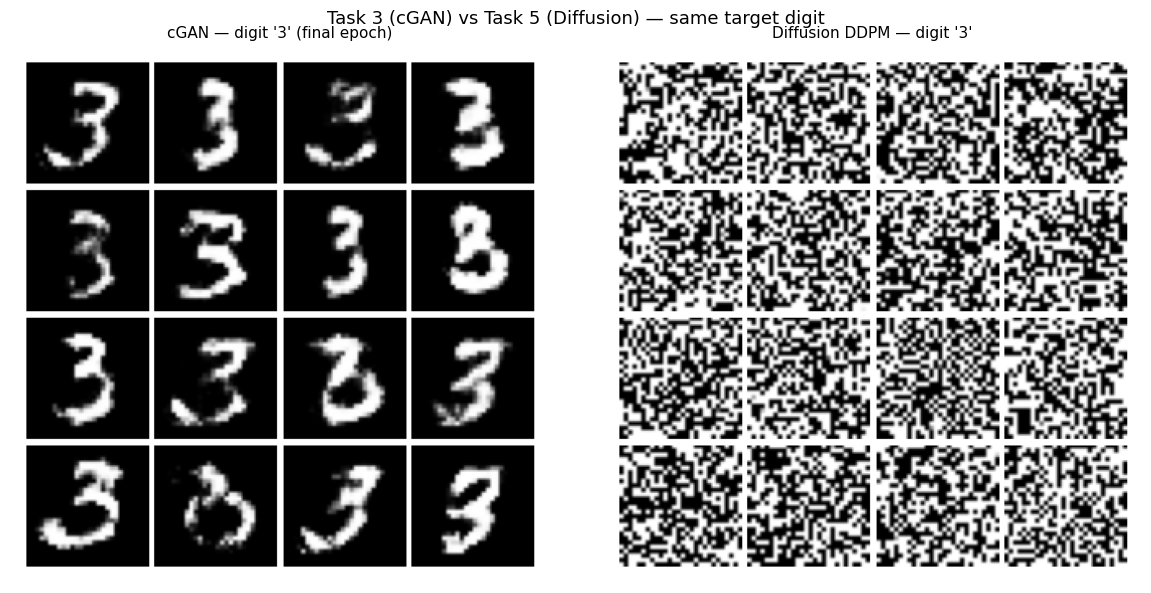

In [4]:
%matplotlib inline

digit    = config.CGAN_TARGET_DIGIT
cgan_dir = os.path.join(config.OUTPUT_DIR, "cgan")
diff_dir = os.path.join(config.OUTPUT_DIR, "diffusion")

# Pick the final cGAN epoch image
cgan_pngs = sorted(f for f in os.listdir(cgan_dir) if f.endswith(".png"))
cgan_path = os.path.join(cgan_dir, cgan_pngs[-1]) if cgan_pngs else None
diff_path = os.path.join(diff_dir, f"digit_{digit}_samples.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

if cgan_path and os.path.exists(cgan_path):
    axes[0].imshow(mpimg.imread(cgan_path))
axes[0].set_title(f"cGAN — digit '{digit}' (final epoch)", fontsize=11)
axes[0].axis("off")

if os.path.exists(diff_path):
    axes[1].imshow(mpimg.imread(diff_path))
axes[1].set_title(f"Diffusion DDPM — digit '{digit}'", fontsize=11)
axes[1].axis("off")

plt.suptitle("Task 3 (cGAN) vs Task 5 (Diffusion) — same target digit", fontsize=13)
plt.tight_layout()
plt.show()


### What is the main difference between GAN and Diffusion? (Task 5 Answer)

**cGAN (Tasks 1–3):**
- The Generator produces an image in a **single forward pass** — very fast at inference.
- Training is **adversarial**: Generator and Discriminator compete. This can cause instability (mode collapse, vanishing gradients).
- The Generator maps noise → image in one step, which limits diversity.

**Diffusion model / DDPM (Task 5):**
- Inference requires **T reverse denoising steps** (T = 1000 here) — slower, but far more stable.
- Training minimises a simple **MSE** between the predicted and actual noise — no adversary, making it much easier to train and scale up.
- The iterative refinement allows the model to capture fine details and produce more diverse, higher-quality images.
- Conditioning (class label, text, another image) can be added at any point in the network, making diffusion models very flexible.

**Why diffusion models have largely replaced GANs:**
GANs require careful balancing of two competing networks and are prone to collapse.
Diffusion models have a stable training signal (simple MSE) and produce higher fidelity results — which is why modern systems like DALL·E 2 and Stable Diffusion are built on diffusion, not GANs.

**Summary:** GANs are fast but hard to train; Diffusion models are slower at inference but more stable to train and produce higher quality, more diverse images.
